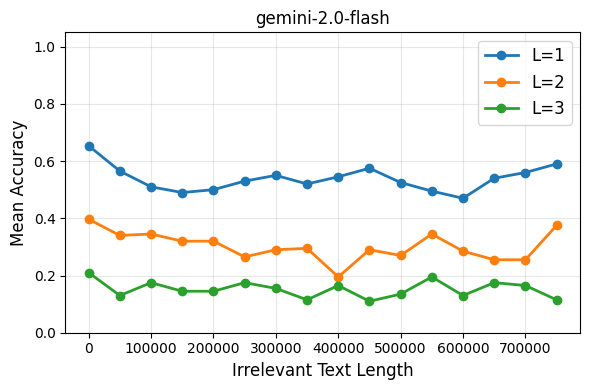

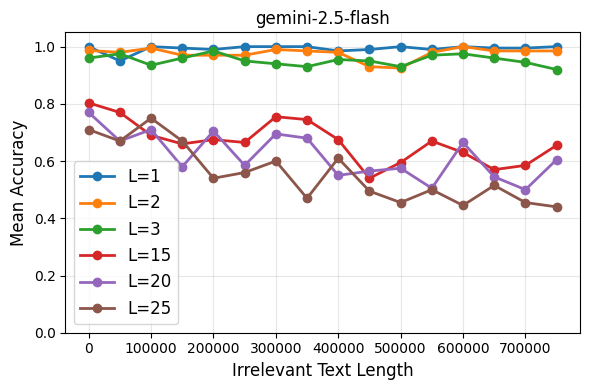

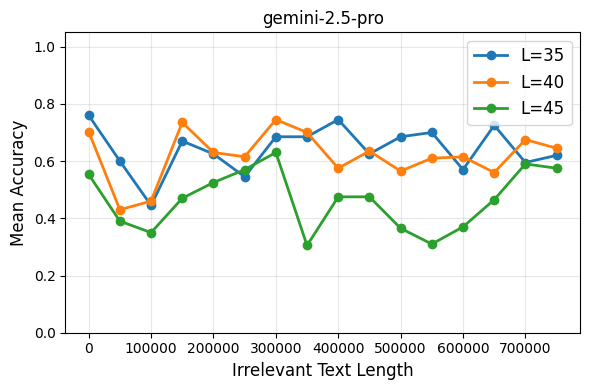

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

model_config = {
    "gemini-2.0-flash": [1, 2, 3],
    "gemini-2.5-flash": [1, 2, 3, 15, 20, 25],
    "gemini-2.5-pro": [35, 40, 45],
}

record_file = 'records'

for model_name, N_values_to_plot in model_config.items():
    # Load CSV file
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/{record_file}/{model_name}/accuracy_summary.csv'
    
    try:
        df = pd.read_csv(csv_path)
        
        # Filter to temperature=0.0 only
        df = df[df['temperature'] == 0.0]
        
        # Create plot
        plt.figure(figsize=(6, 4))
        
        # Plot only the specified N values
        for N in N_values_to_plot:
            # Filter data for this N value
            n_data = df[df['N'] == N]
            
            if len(n_data) > 0:  # Only plot if data exists
                # Group by L_irr and calculate mean accuracy
                grouped = n_data.groupby('L_irr')['accuracy'].mean()
                
                # Plot
                plt.plot(grouped.index, grouped.values, marker='o', label=f'L={N}', linewidth=2)
            else:
                print(f"Warning: No data found for N={N} in {model_name}")
        
        plt.xlabel('Irrelevant Text Length', fontsize=12)
        plt.ylabel('Mean Accuracy', fontsize=12)
        plt.title(f'{model_name}', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")

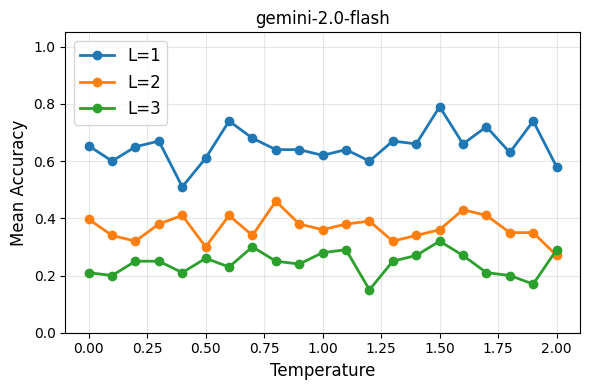

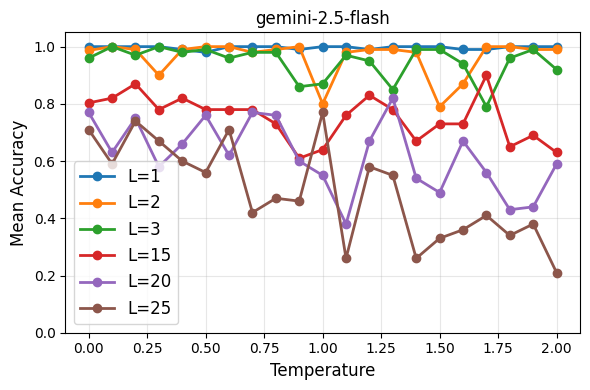

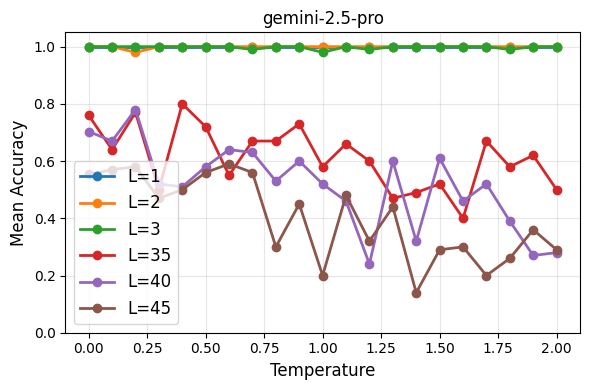

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

model_config = {
    "gemini-2.0-flash": [1,2,3],
    "gemini-2.5-flash": [1, 2, 3, 15, 20, 25],
    "gemini-2.5-pro": [1, 2, 3, 35, 40, 45],
}

record_file = 'records'

for model_name, N_values_to_plot in model_config.items():
    # Load CSV file
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/{record_file}/{model_name}/accuracy_summary.csv'
    
    try:
        df = pd.read_csv(csv_path)
        
        df = df[df['L_irr'] == 0]
        
        # Create plot
        plt.figure(figsize=(6, 4))
        
        # Plot only the specified N values
        for N in N_values_to_plot:
            # Filter data for this N value
            n_data = df[df['N'] == N]
            
            if len(n_data) > 0:  # Only plot if data exists
                # Group by temperature and calculate mean accuracy
                grouped = n_data.groupby('temperature')['accuracy'].mean()
                
                # Plot
                plt.plot(grouped.index, grouped.values, marker='o', label=f'L={N}', linewidth=2)
            else:
                print(f"Warning: No data found for L={N} in {model_name}")
        
        plt.xlabel('Temperature', fontsize=12)
        plt.ylabel('Mean Accuracy', fontsize=12)
        plt.title(f'{model_name}', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")

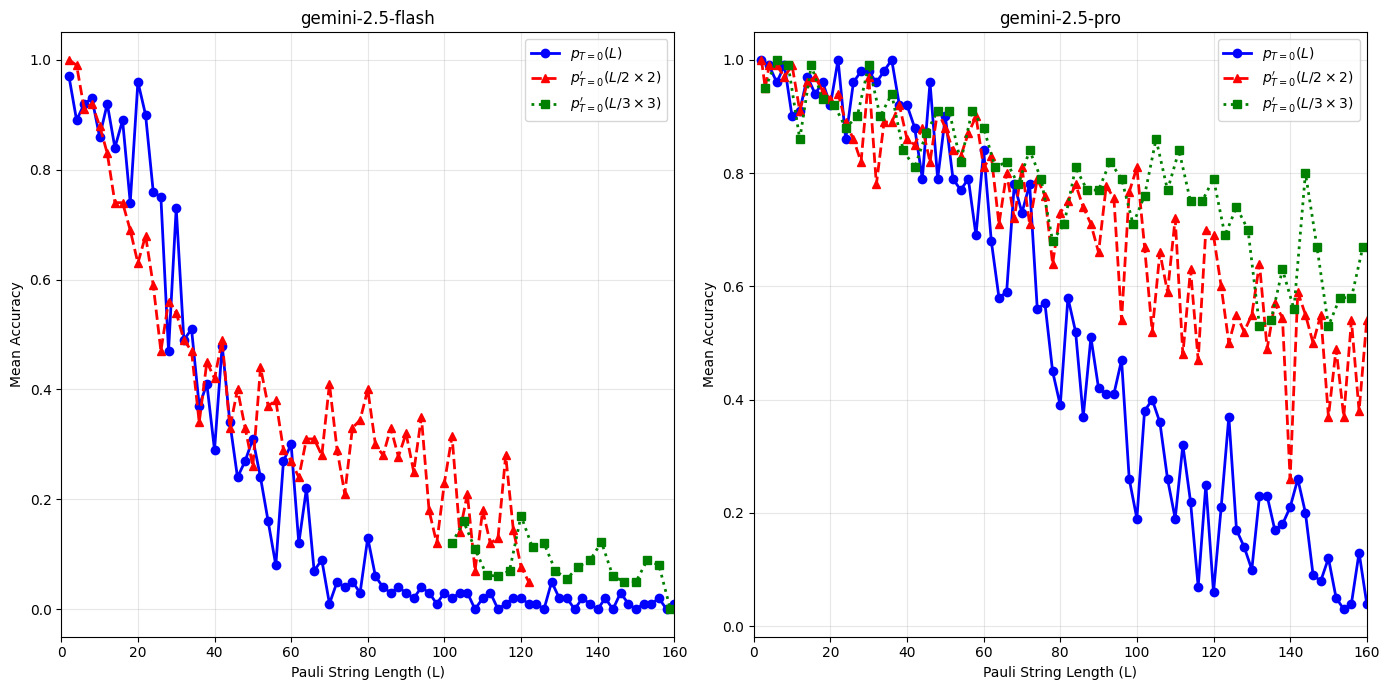

In [93]:
# Individual plots for each model in subplots
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = ["gemini-2.5-flash", "gemini-2.5-pro"]

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(14, 7))
#fig.suptitle(r'$p_{T=0}(L)$ vs $p^{\prime}_{T=0}(L/2 \times 2)$: Direct vs Divide-and-Conquer', fontsize=16)

for idx, model in enumerate(models):
    ax = axes[idx]
    
    # === DIRECT MULTIPLICATION DATA ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & (df['L_irr'] == 0)]
        grouped = df_clean.groupby('N')['accuracy'].mean()
        
        if not grouped.empty:
            ax.plot(grouped.index, grouped.values, marker='o', color='blue', 
                   label=r'$p_{T=0}(L)$', linewidth=2, linestyle='-')
            
    except FileNotFoundError:
        pass

    # === DIVIDE-AND-CONQUER DATA (N//2) ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & 
                        (df['workflow_success'] == True) & 
                        (df['chunk_size'] == df['N'] // 2)]
        grouped = df_clean.groupby('N')['accuracy'].mean()
        
        if not grouped.empty:
            ax.plot(grouped.index, grouped.values, marker='^', color='red', 
                    label=r'$p^{\prime}_{T=0}(L/2 \times 2)$', linewidth=2, linestyle='--')
            
    except FileNotFoundError:
        pass
    
    # === DIVIDE-AND-CONQUER DATA (N//3) ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & 
                        (df['workflow_success'] == True) & 
                        (df['chunk_size'] == df['N'] // 3)]
        grouped = df_clean.groupby('N')['accuracy'].mean()
        
        if not grouped.empty:
            ax.plot(grouped.index, grouped.values, marker='s', color='green', 
                    label=r'$p^{\prime}_{T=0}(L/3 \times 3)$', linewidth=2, linestyle=':')
            
    except FileNotFoundError:
        pass
    
    # Formatting for each subplot
    ax.set_xlabel('Pauli String Length (L)')
    ax.set_ylabel('Mean Accuracy')
    ax.set_title(f'{model}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 160)
    #ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


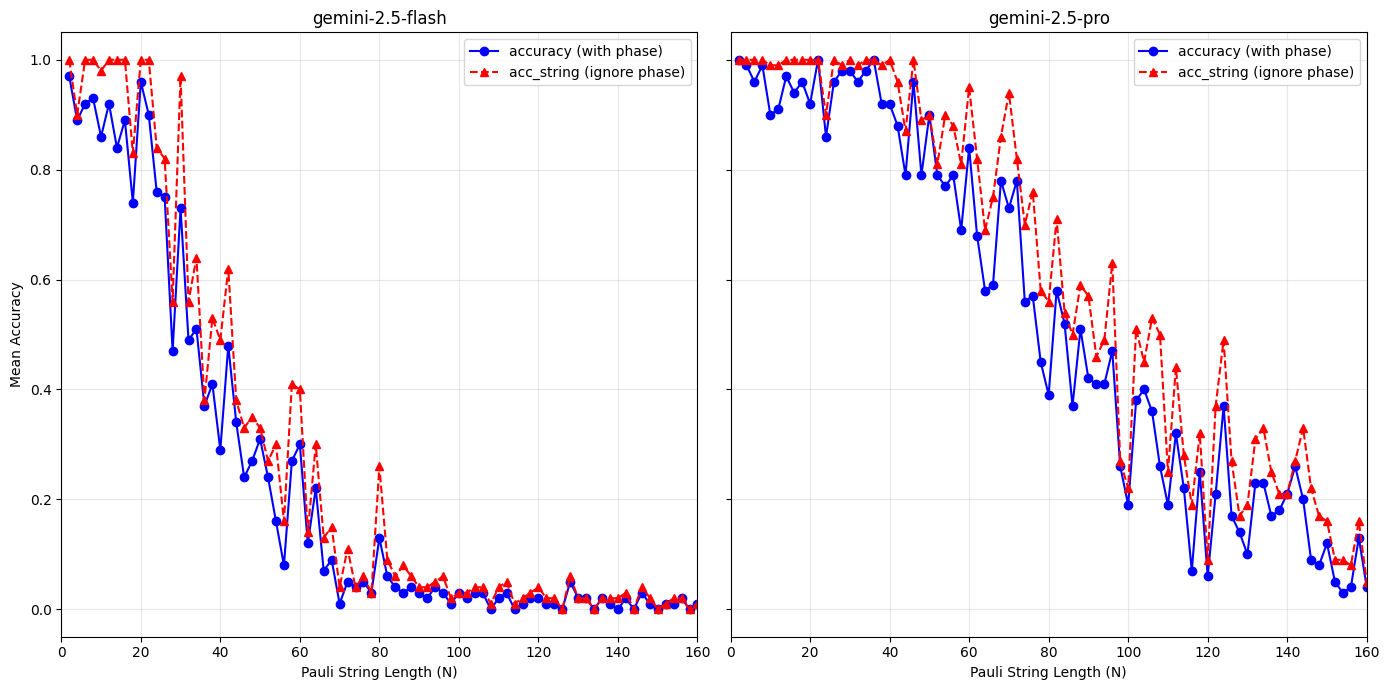

In [96]:
# Two subplots (axes): left = gemini-2.5-flash, right = gemini-2.5-pro
import pandas as pd
import matplotlib.pyplot as plt

models = ["gemini-2.5-flash", "gemini-2.5-pro"]
csv_tpl = "/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv"

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

for ax, model in zip(axes, models):
    df = pd.read_csv(csv_tpl.format(model=model))
    df = df[(df["temperature"] == 0.0) & (df["L_irr"] == 0)]
    if "acc_string" in df.columns:
        df["acc_string"] = pd.to_numeric(df["acc_string"], errors="coerce")

    acc_phase = df.groupby("N")["accuracy"].mean()
    acc_nophase = df.groupby("N")["acc_string"].mean() if "acc_string" in df.columns else None

    if not acc_phase.empty:
        ax.plot(acc_phase.index, acc_phase.values, marker="o", linestyle="-", color="blue",
                label="accuracy (with phase)")
    if acc_nophase is not None and not acc_nophase.empty:
        ax.plot(acc_nophase.index, acc_nophase.values, marker="^", linestyle="--", color="red",
                label="acc_string (ignore phase)")

    ax.set_xlabel("Pauli String Length (N)")
    ax.set_title(model)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 160)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

axes[0].set_ylabel("Mean Accuracy")
plt.tight_layout()
plt.show()

/Users/hwanda/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


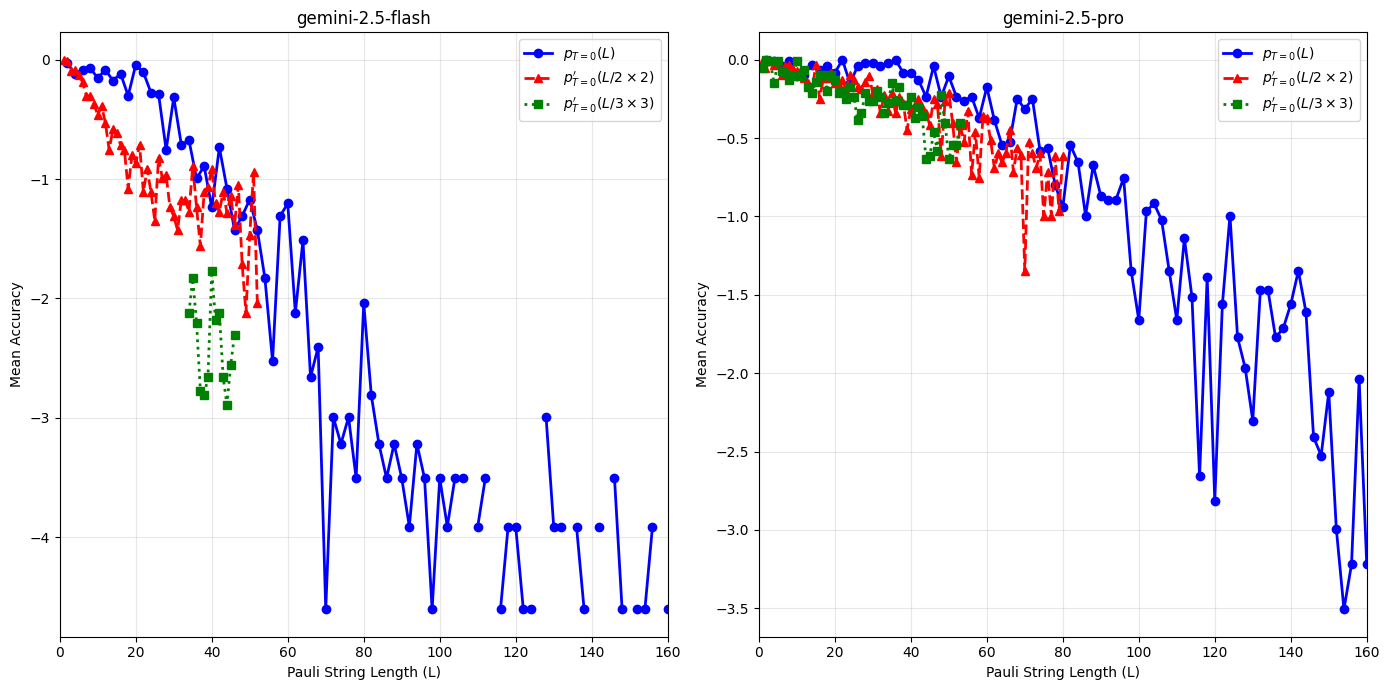

In [76]:
# Individual plots for each model in subplots
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = ["gemini-2.5-flash", "gemini-2.5-pro"]

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(14, 7))
#fig.suptitle(r'$p_{T=0}(L)$ vs $p^{\prime}_{T=0}(L/2 \times 2)$: Direct vs Divide-and-Conquer', fontsize=16)

for idx, model in enumerate(models):
    ax = axes[idx]
    
    # === DIRECT MULTIPLICATION DATA ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & (df['L_irr'] == 0)]
        grouped = np.log(df_clean.groupby('N')['accuracy'].mean())
        
        if not grouped.empty:
            ax.plot(grouped.index, grouped.values, marker='o', color='blue', 
                   label=r'$p_{T=0}(L)$', linewidth=2, linestyle='-')
            
    except FileNotFoundError:
        pass

    # === DIVIDE-AND-CONQUER DATA (N//2) ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & 
                        (df['workflow_success'] == True) & 
                        (df['chunk_size'] == df['N'] // 2)]
        grouped = np.log(df_clean.groupby('N')['accuracy'].mean())
        
        if not grouped.empty:
            ax.plot(grouped.index/2, grouped.values, marker='^', color='red', 
                    label=r'$p^{\prime}_{T=0}(L/2 \times 2)$', linewidth=2, linestyle='--')
            
    except FileNotFoundError:
        pass
    
    # === DIVIDE-AND-CONQUER DATA (N//3) ===
    try:
        csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
        df = pd.read_csv(csv_path)
        df_clean = df[(df['temperature'] == 0.0) & 
                        (df['workflow_success'] == True) & 
                        (df['chunk_size'] == df['N'] // 3)]
        grouped = np.log(df_clean.groupby('N')['accuracy'].mean())
        
        if not grouped.empty:
            ax.plot(grouped.index/3, grouped.values, marker='s', color='green', 
                    label=r'$p^{\prime}_{T=0}(L/3 \times 3)$', linewidth=2, linestyle=':')
            
    except FileNotFoundError:
        pass
    
    # Formatting for each subplot
    ax.set_xlabel('Pauli String Length (L)')
    ax.set_ylabel('Mean Accuracy')
    ax.set_title(f'{model}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 160)
    #ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


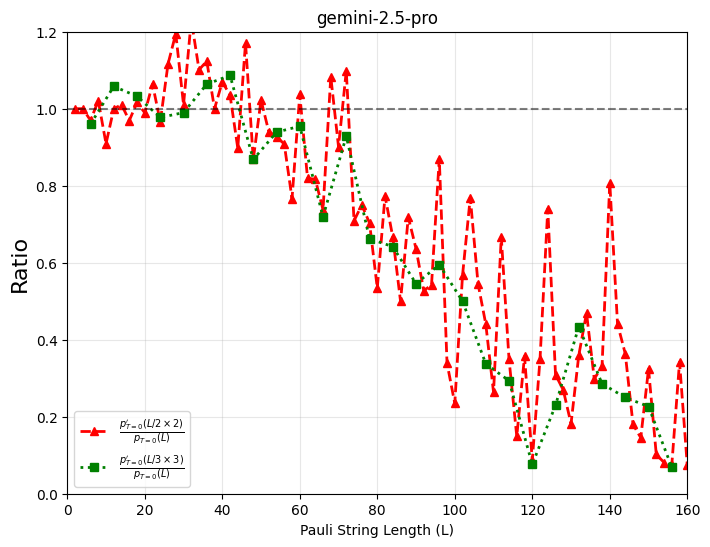

In [74]:
# Plot ratio between direct and divide-and-conquer
import pandas as pd
import matplotlib.pyplot as plt

models = ["gemini-2.5-pro"]

plt.figure(figsize=(8, 6))

for model in models:
    # Load direct data
    direct_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
    df_direct = pd.read_csv(direct_path)
    direct_clean = df_direct[(df_direct['temperature'] == 0.0) & (df_direct['L_irr'] == 0)]
    direct_grouped = direct_clean.groupby('N')['accuracy'].mean()
    
    # Load D&C data of N // 2
    dc_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
    df_dc = pd.read_csv(dc_path)
    dc_clean = df_dc[(df_dc['temperature'] == 0.0) & 
                     (df_dc['workflow_success'] == True) & 
                     (df_dc['chunk_size'] == df_dc['N'] // 2)]
    dc_grouped = dc_clean.groupby('N')['accuracy'].mean()
    
    # Calculate ratio (D&C / Direct)
    common_N = direct_grouped.index.intersection(dc_grouped.index)
    ratio = direct_grouped[common_N]/dc_grouped[common_N]
    
    plt.plot(common_N, ratio, marker='^', color='red', label=r'$\frac{p^{\prime}_{T=0}(L/2 \times 2)}{p_{T=0}(L)}$', linewidth=2, linestyle='--')

    # Load D&C data of N // 3
    dc_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
    df_dc = pd.read_csv(dc_path)
    dc_clean = df_dc[(df_dc['temperature'] == 0.0) & 
                     (df_dc['workflow_success'] == True) & 
                     (df_dc['chunk_size'] == df_dc['N'] // 3)]
    dc_grouped = dc_clean.groupby('N')['accuracy'].mean()

    # Calculate ratio (D&C / Direct)
    common_N = direct_grouped.index.intersection(dc_grouped.index)
    ratio = direct_grouped[common_N]/dc_grouped[common_N]
    
    plt.plot(common_N, ratio, marker='s', color='green', 
                    label=r'$\frac{p^{\prime}_{T=0}(L/3 \times 3)}{p_{T=0}(L)}$', linewidth=2, linestyle=':')

    plt.xlabel('Pauli String Length (L)')
    plt.ylabel('Ratio', fontsize=16)
    plt.title(f'{model}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal Performance')
    plt.xlim(0, 160)
    plt.ylim(0, 1.2)
    plt.show()


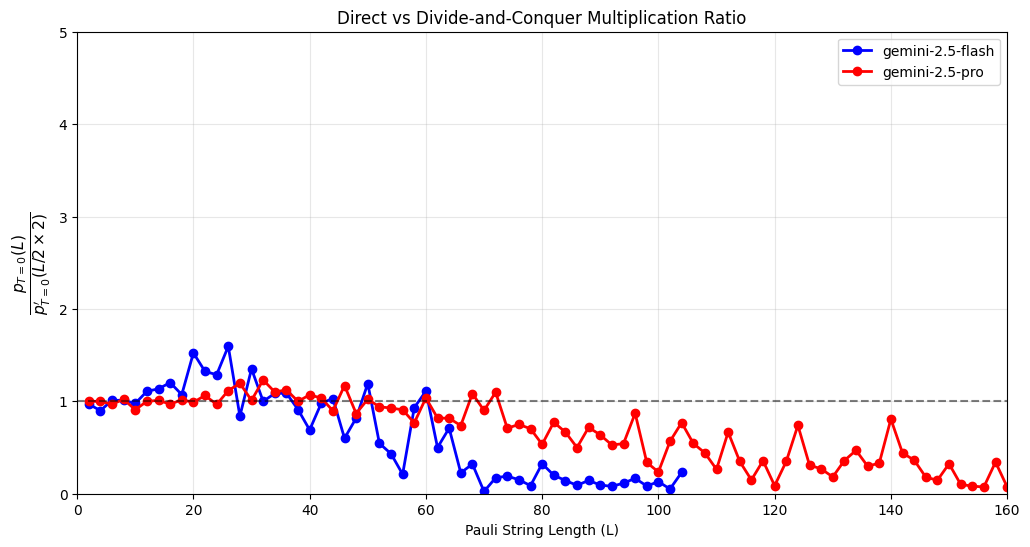

In [53]:
# Plot ratio between direct and divide-and-conquer
import pandas as pd
import matplotlib.pyplot as plt

models = ["gemini-2.5-flash", "gemini-2.5-pro"]
colors = ["blue", "red"]

plt.figure(figsize=(12, 6))

for model, color in zip(models, colors):
    # Load direct data
    direct_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
    df_direct = pd.read_csv(direct_path)
    direct_clean = df_direct[(df_direct['temperature'] == 0.0) & (df_direct['L_irr'] == 0)]
    direct_grouped = direct_clean.groupby('N')['accuracy'].mean()
    
    # Load D&C data
    dc_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
    df_dc = pd.read_csv(dc_path)
    dc_clean = df_dc[(df_dc['temperature'] == 0.0) & 
                     (df_dc['workflow_success'] == True) & 
                     (df_dc['chunk_size'] == df_dc['N'] // 2)]
    dc_grouped = dc_clean.groupby('N')['accuracy'].mean()
    
    # Calculate ratio (D&C / Direct)
    common_N = direct_grouped.index.intersection(dc_grouped.index)
    ratio = direct_grouped[common_N] / dc_grouped[common_N]
    
    plt.plot(common_N, ratio, marker='o', color=color, label=model, linewidth=2)

plt.xlabel('Pauli String Length (L)')
plt.ylabel(r'$\frac{p_{T=0}(L)}{p^{\prime}_{T=0}(L/2 \times 2)}$', fontsize=16)
plt.title('Direct vs Divide-and-Conquer Multiplication Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal Performance')
plt.xlim(0, 160)
plt.ylim(0, 5)
plt.show()


In [92]:
# Scan all JSON records, print string-only accuracy, and write acc_string into accuracy_summary.csv
import os, glob, json, re
import pandas as pd
import mcp_server as mcp

model = "gemini-2.5-flash"
DIR = f"/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}"
CSV_PATH = os.path.join(DIR, "accuracy_summary.csv")
TEXT_RE = re.compile(r"text='([^']+)'")

def extract_text(entry: str) -> str:
    m = TEXT_RE.search(entry or "")
    return m.group(1).strip() if m else ""

# Load CSV once; add column if missing
summary = pd.read_csv(CSV_PATH)
if "acc_string" not in summary.columns:
    summary["acc_string"] = pd.NA

files = sorted(glob.glob(os.path.join(DIR, "record_*.json")))
for fp in files:
    try:
        with open(fp, "r") as f:
            rec = json.load(f)
        llm_answers = rec.get("llm_answers", []) or []
        correct_texts = [extract_text(e) for e in rec.get("correct_answers", [])]
        n = min(len(llm_answers), len(correct_texts))
        ok = 0
        for a, b in zip(llm_answers[:n], correct_texts[:n]):
            try:
                ok += int(mcp.PauliTerm(text=a).pauli_string == mcp.PauliTerm(text=b).pauli_string)  # ignore the phase factor
            except Exception:
                pass
        acc = ok / n if n else 0.0
        print(f"{os.path.basename(fp)} | model={rec.get('model')} N={rec.get('N')} batch={len(llm_answers)} acc={acc:.3f} ({ok}/{n})")

        # Update the matching row in CSV using timestamp + iteration (+ N, model as safeguards)
        ts = rec.get("timestamp")
        it = rec.get("iteration")
        N = rec.get("N")
        mdl = rec.get("model")
        if ts is not None and it is not None:
            mask = (
                (summary["timestamp"] == ts)
                & (summary["iteration"] == it)
                & (summary["N"] == N)
                & (summary["model"] == mdl)
            )
            if mask.any():
                summary.loc[mask, "acc_string"] = acc
    except Exception as e:
        print(f"{os.path.basename(fp)} | ERROR: {e}")

# Write back once
summary.to_csv(CSV_PATH, index=False)
print(f"Updated: {CSV_PATH}")

record_N100_batch10_L_irr0_temp0.0_iter10_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.000 (0/10)
record_N100_batch10_L_irr0_temp0.0_iter1_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.000 (0/10)
record_N100_batch10_L_irr0_temp0.0_iter2_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.000 (0/10)
record_N100_batch10_L_irr0_temp0.0_iter3_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.000 (0/10)
record_N100_batch10_L_irr0_temp0.0_iter4_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.000 (0/10)
record_N100_batch10_L_irr0_temp0.0_iter5_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.000 (0/10)
record_N100_batch10_L_irr0_temp0.0_iter6_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.000 (0/10)
record_N100_batch10_L_irr0_temp0.0_iter7_20250819_020959.json | model=gemini-2.5-flash N=100 batch=10 acc=0.100 (1/10)
record_N100_batch10_L_irr0_temp0.0_iter8_202508

In [89]:
import mcp_server as mcp

a = "-iI_0 Z_1 Y_2"
b = "+iI_0 Z_1 Y_2"

print(mcp.PauliTerm(text=a) == mcp.PauliTerm(text=b))

False


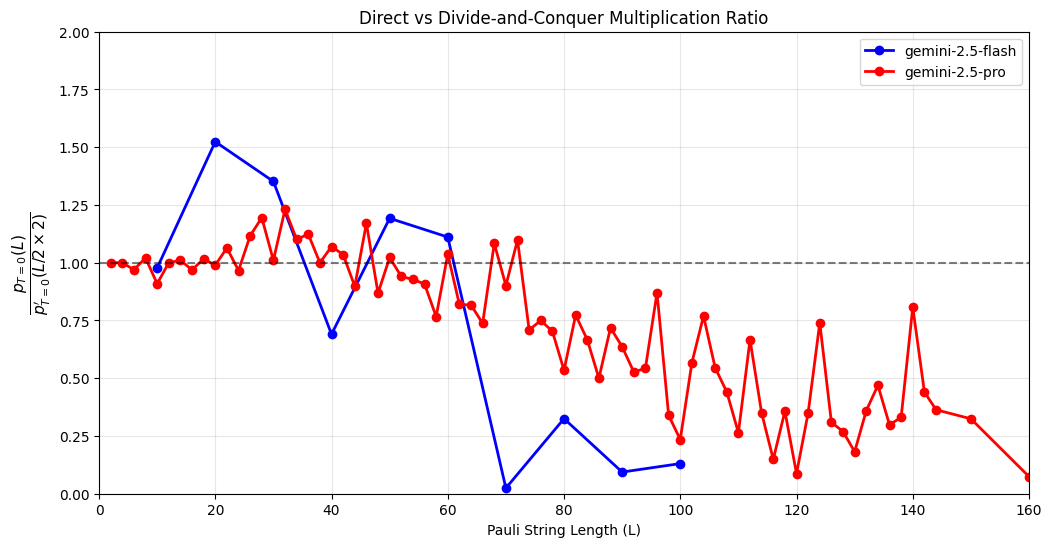

In [40]:
# Plot ratio between direct and divide-and-conquer
import pandas as pd
import matplotlib.pyplot as plt

models = ["gemini-2.5-flash", "gemini-2.5-pro"]
colors = ["blue", "red"]

plt.figure(figsize=(12, 6))

for model, color in zip(models, colors):
    # Load direct data
    direct_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
    df_direct = pd.read_csv(direct_path)
    direct_clean = df_direct[(df_direct['temperature'] == 0.0) & (df_direct['L_irr'] == 0)]
    direct_grouped = direct_clean.groupby('N')['accuracy'].mean()
    
    # Load D&C data
    dc_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/divide_and_conquer/records/{model}/accuracy_summary.csv'
    df_dc = pd.read_csv(dc_path)
    dc_clean = df_dc[(df_dc['temperature'] == 0.0) & 
                     (df_dc['workflow_success'] == True) & 
                     (df_dc['chunk_size'] == df_dc['N'] // 2)]
    dc_grouped = dc_clean.groupby('N')['accuracy'].mean()
    
    # Calculate ratio (D&C / Direct)
    common_N = direct_grouped.index.intersection(dc_grouped.index)
    ratio = direct_grouped[common_N] / dc_grouped[common_N]
    
    plt.plot(common_N, ratio, marker='o', color=color, label=model, linewidth=2)

plt.xlabel('Pauli String Length (L)')
plt.ylabel(r'$\frac{p_{T=0}(L)}{p^{\prime}_{T=0}(L/2 \times 2)}$', fontsize=16)
plt.title('Direct vs Divide-and-Conquer Multiplication Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal Performance')
plt.xlim(0, 160)
plt.ylim(0, 2)
plt.show()
